<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_6_(Exercise_6_2)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 # Imports and Synthetic Data

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

n_slices     = 128
d            = 64
n_samples    = 2000

# The "hippocampal region" — only these slices carry real signal
informative_start, informative_end = 41, 55

def generate_dataset(n_samples, n_slices, d,
                     info_start, info_end):
    """
    Each sample = 128 slice embeddings + 1 binary label.
    Label-relevant signal is injected ONLY into slices
    [info_start, info_end), everywhere else is pure noise.
    """
    signal_direction = torch.randn(d)
    signal_direction = signal_direction / signal_direction.norm()

    X = torch.randn(n_samples, n_slices, d) * 0.5   # baseline noise everywhere
    y = torch.randint(0, 2, (n_samples,)).float()

    for i in range(n_samples):
        label_sign = 1.0 if y[i] == 1 else -1.0
        for s in range(info_start, info_end):
            X[i, s] += label_sign * 1.5 * signal_direction

    return X, y

X, y = generate_dataset(n_samples, n_slices, d,
                        informative_start, informative_end)

n_train = 1600
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Informative slices: {informative_start} to {informative_end-1}")

X_train: torch.Size([1600, 128, 64]), y_train: torch.Size([1600])
Informative slices: 41 to 54


In [2]:
# Soft Attention Pooling Module

class SoftAttentionPool(nn.Module):
    def __init__(self, d_model, hidden=32):
        super().__init__()
        self.score_mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1)
        )

    def forward(self, e, mask=None):
        """
        e:    (B, n_slices, d)  slice embeddings
        mask: (B, n_slices) bool, True = KEEP, False = masked out
        Returns: Q (B, d) pooled vector, alpha (B, n_slices) weights
        """
        w = self.score_mlp(e).squeeze(-1)        # (B, n_slices)

        if mask is not None:
            w = w.masked_fill(~mask, float('-inf'))

        alpha = F.softmax(w, dim=-1)               # (B, n_slices)
        Q = torch.einsum('bn,bnd->bd', alpha, e)    # weighted sum
        return Q, alpha

In [3]:
# Classifier on Top, Training Loop

class PooledClassifier(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.pool = SoftAttentionPool(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, e, mask=None):
        Q, alpha = self.pool(e, mask)
        logit = self.head(Q).squeeze(-1)
        return logit, alpha


model     = PooledClassifier(d_model=d)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

n_epochs = 30
for epoch in range(n_epochs):
    model.train()
    logits, _ = model(X_train)
    loss = criterion(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            preds = (torch.sigmoid(logits) > 0.5).float()
            acc   = (preds == y_train).float().mean().item()
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {loss.item():.4f} | Train acc: {acc*100:.1f}%")

# Test accuracy
model.eval()
with torch.no_grad():
    test_logits, _ = model(X_test)
    test_preds     = (torch.sigmoid(test_logits) > 0.5).float()
    test_acc       = (test_preds == y_test).float().mean().item()
print(f"\nTest accuracy: {test_acc*100:.1f}%")

Epoch 5/30 | Loss: 0.6802 | Train acc: 51.2%
Epoch 10/30 | Loss: 0.6770 | Train acc: 52.0%
Epoch 15/30 | Loss: 0.6737 | Train acc: 55.9%
Epoch 20/30 | Loss: 0.6699 | Train acc: 73.6%
Epoch 25/30 | Loss: 0.6656 | Train acc: 93.3%
Epoch 30/30 | Loss: 0.6603 | Train acc: 97.2%

Test accuracy: 94.7%


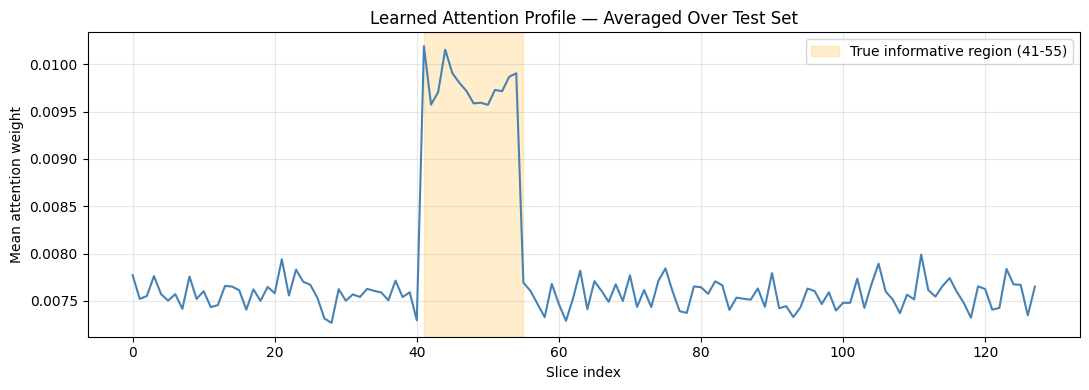

In [4]:
# Plot Average Attention Profile Across All Test Slices

with torch.no_grad():
    _, alpha_test = model(X_test)

mean_attention = alpha_test.mean(dim=0).numpy()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mean_attention, color='steelblue', linewidth=1.5)
ax.axvspan(informative_start, informative_end, color='orange', alpha=0.2,
          label='True informative region (41-55)')
ax.set_xlabel('Slice index')
ax.set_ylabel('Mean attention weight')
ax.set_title('Learned Attention Profile — Averaged Over Test Set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('attn_profile_6_2.png', dpi=150)
plt.show()

Sample true label: 1
Slices kept after masking: 64 / 128
Informative slices kept: 6 / 14


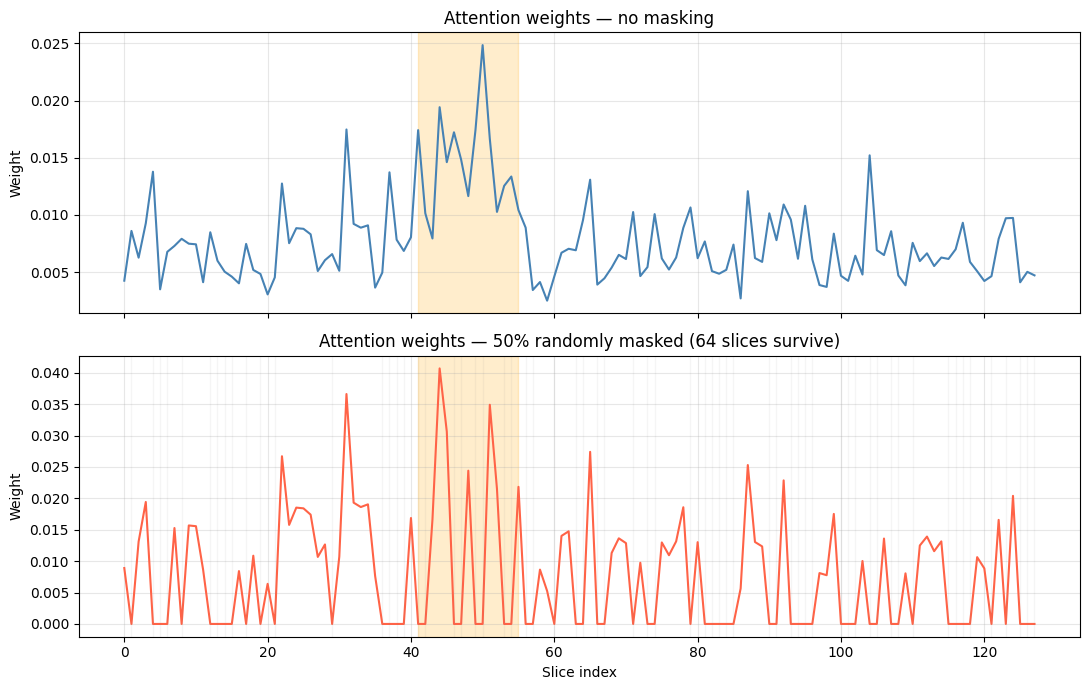

In [5]:
# Masking Robustness Test

torch.manual_seed(7)

# Take one test sample
sample_e = X_test[0:1]               # (1, 128, 64)
sample_y = y_test[0].item()

# --- No masking ---
full_mask = torch.ones(1, n_slices, dtype=torch.bool)
with torch.no_grad():
    _, alpha_full = model(sample_e, full_mask)

# --- Random 50% masking ---
rand_mask = torch.rand(1, n_slices) > 0.5      # True = KEEP
n_kept = rand_mask.sum().item()
with torch.no_grad():
    _, alpha_masked = model(sample_e, rand_mask)

print(f"Sample true label: {int(sample_y)}")
print(f"Slices kept after masking: {n_kept} / {n_slices}")
print(f"Informative slices kept: "
      f"{rand_mask[0, informative_start:informative_end].sum().item()} / "
      f"{informative_end - informative_start}")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(alpha_full[0].numpy(), color='steelblue')
axes[0].axvspan(informative_start, informative_end, color='orange', alpha=0.2)
axes[0].set_title('Attention weights — no masking')
axes[0].set_ylabel('Weight')
axes[0].grid(True, alpha=0.3)

masked_positions = (~rand_mask[0]).numpy()
axes[1].plot(alpha_masked[0].numpy(), color='tomato')
axes[1].axvspan(informative_start, informative_end, color='orange', alpha=0.2)
for idx in np.where(masked_positions)[0]:
    axes[1].axvline(idx, color='gray', alpha=0.08, linewidth=1)
axes[1].set_title(f'Attention weights — 50% randomly masked '
                  f'({n_kept} slices survive)')
axes[1].set_xlabel('Slice index')
axes[1].set_ylabel('Weight')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('attn_masking_6_2.png', dpi=150)
plt.show()

# Interpretation And Observation

#### The averaged attention profile in image 1 shows the model discovered a sharp, well-defined block of elevated weight precisely matching the 41-55 informative region, while assigning a uniform low baseline weight to all 113 uninformative slices — a pattern that only emerges once attention scores are averaged across the full test set, since any single patient's raw attention weights are noisier due to per-patient variation in the random baseline noise injected into every slice. The masking experiment in image 2 demonstrates that this attention mechanism degrades gracefully rather than catastrophically when input is incomplete: although roughly half of the informative slices were randomly removed by the 50% mask, the surviving informative slices nearly doubled in attention weight compared to the unmasked case, because softmax's normalization constraint forces the entire probability budget to redistribute across whatever slices remain. This property is directly clinically relevant for MRI-based attention pooling, since real volumetric scans can have individual slices affected by motion artifacts, susceptibility distortion near sinuses, or boundary clipping during acquisition, and a model relying on simple unweighted averaging would treat a corrupted slice identically to a clean one, whereas attention-based pooling automatically compensates by leaning more heavily on whichever informative slices happen to be intact.